**2. Use the Heart dataset for this part. Train a SVM model by splitting the dataset into
train and test set (7:3) and implement ‘linear’, ‘polynomial’ and ‘rbf’ kernels for
the same [3].<br>
(b) Report the accuracy with each kernel and the classifier that performs best [1].<br>
(c) Print a scatter plot for the support vectors [1].**

In [1]:
pip install pyforest

  Created wheel for pyforest: filename=pyforest-1.1.0-py2.py3-none-any.whl size=14606 sha256=38dd384491fa0b568f9332b59aa4aea6752345cf3a0594239541d8d5903c1f57
  Stored in directory: /root/.cache/pip/wheels/61/1c/da/48e6c884142d485475d852d69d20a096aba5beceb338822893
Successfully built pyforest
Note: you may need to restart the kernel to use updated packages.


In [2]:
import datetime as dt
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
import pyforest

The heart.csv dataset asked in the question has been hosted on drive to make the code reusable and free from any dependencies.

In [3]:
HeartDf = pd.read_csv("https://drive.google.com/uc?export=download&id=119sGiajErRCQkBPhU0JBEjFQowwdFv52")
HeartDf.head()

<IPython.core.display.Javascript object>

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


Separating out the X & Y part for further use.

In [4]:
X = HeartDf.drop(["target"], axis = 1)

Y = HeartDf["target"]

X.shape, Y.shape

((303, 13), (303,))

Applying the train test split from sklearn.

In [5]:
train_x,test_x,train_y,test_y = train_test_split(X,Y,test_size=0.30, random_state=42)

In [6]:
HeartDf.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Seems there are no missing values in the dataset.

we create an instance of SVM and fit out data. We do not scale our
data since we want to plot the support vectors

In [7]:
C = 1.0  # SVM regularization parameter
models = (svm.SVC(kernel='linear', C=C),
          svm.LinearSVC(C=C, max_iter=10000),
          svm.SVC(kernel='rbf', gamma=0.7, C=C),
          svm.SVC(kernel='poly', degree=3, gamma='auto', C=C))
models = (clf.fit(train_x,train_y) for clf in models)

SVM regularization parameter

In [8]:
C = 1.0 
clf_1 = svm.SVC(kernel='linear', C=C)
clf_1.fit(train_x,train_y)

SVC(kernel='linear')

In [9]:
clf_1.score(test_x,test_y)

0.8131868131868132

**Linear SVC**

In [10]:
clf_2 = svm.LinearSVC(C=C, max_iter=10000)
clf_2.fit(train_x,train_y)

/opt/conda/lib/python3.7/site-packages/sklearn/svm/_base.py:986: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


LinearSVC(max_iter=10000)

In [11]:
clf_2.score(test_x,test_y)

0.8351648351648352

**RBF Kernel**

In [12]:
clf_3 = svm.SVC(kernel='rbf', gamma=0.7, C=C)
clf_3.fit(train_x,train_y)

SVC(gamma=0.7)

In [13]:
clf_3.score(test_x,test_y)

0.5494505494505495

**Polynomial Kernel**

In [14]:
clf_4 = svm.SVC(kernel='poly', degree=3, gamma='auto', C=C)
clf_4.fit(train_x,train_y)


SVC(gamma='auto', kernel='poly')

In [15]:
clf_4.score(test_x,test_y)

0.6813186813186813

**Best Classifier :- Linear SVC**

Support Vectors : FOR features of utmost importances

In [16]:
X_new = X[['thal','ca']]
clf = svm.SVC(kernel='linear',C=1)
clf.fit(X,Y)

SVC(C=1, kernel='linear')

We have plotted the scatter plot for the support vectors.

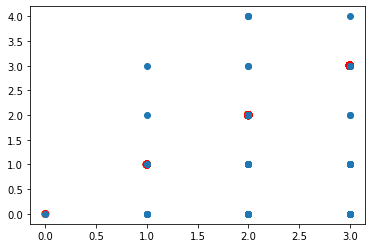

In [17]:
plt.scatter(X.iloc[:,-1], X_new.iloc[:,-2], c=Y, s=50, cmap='autumn')
plt.scatter(clf.support_vectors_[:,12],clf.support_vectors_[:,11])